# (10) Kyoto16, gaussian-sigmoid: ```z-100/128/192/256```, (16, 32.0)

project = ```P-VIB```, host = ```mach```, device = ```cuda:1```

**Motivation**: <br>

Reproduce

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE'))
from figures.convergence import plot_convergence
from figures.imgs import plot_weights
from figures.fighelper import *
from main.train import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

## Fit: ```z-100, (16, 32.0)```

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 100
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 32.0

cfg_tr['epochs']= 2000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |   26.2 K   |
|     ———     |    ———     |
|    layer    |   26.2 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[100]_u-(7,2),du-(7,3)_<grad|lin>
b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_13,09:28)

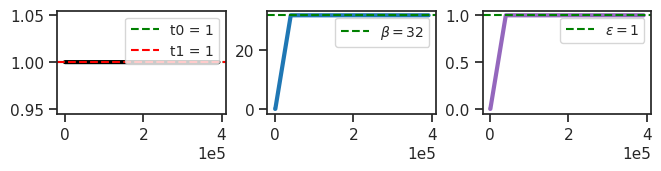

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

392000

In [6]:
print(tr.model.layer)

GaussianSigmoidLayer(input_dim=256, latent_dim=100, temperature=1, beta_inner=1, eps=1)

In [7]:
# cm = f""
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 2000, avg loss: 215.436: 100%|████| 2000/2000 [9:50:01<00:00, 17.70s/it]


In [8]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0468], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0090], device='cuda:1', grad_fn=<ExpBackward0>))

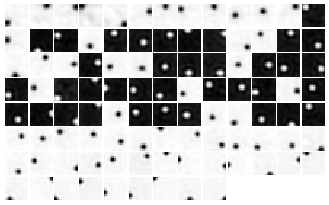

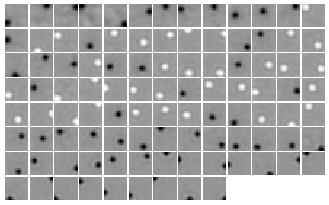

In [9]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=8, dpi=50)
tr.model.show(order=np.argsort(u0), nrows=8, dpi=50, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:49<00:00, 24.97s/it]


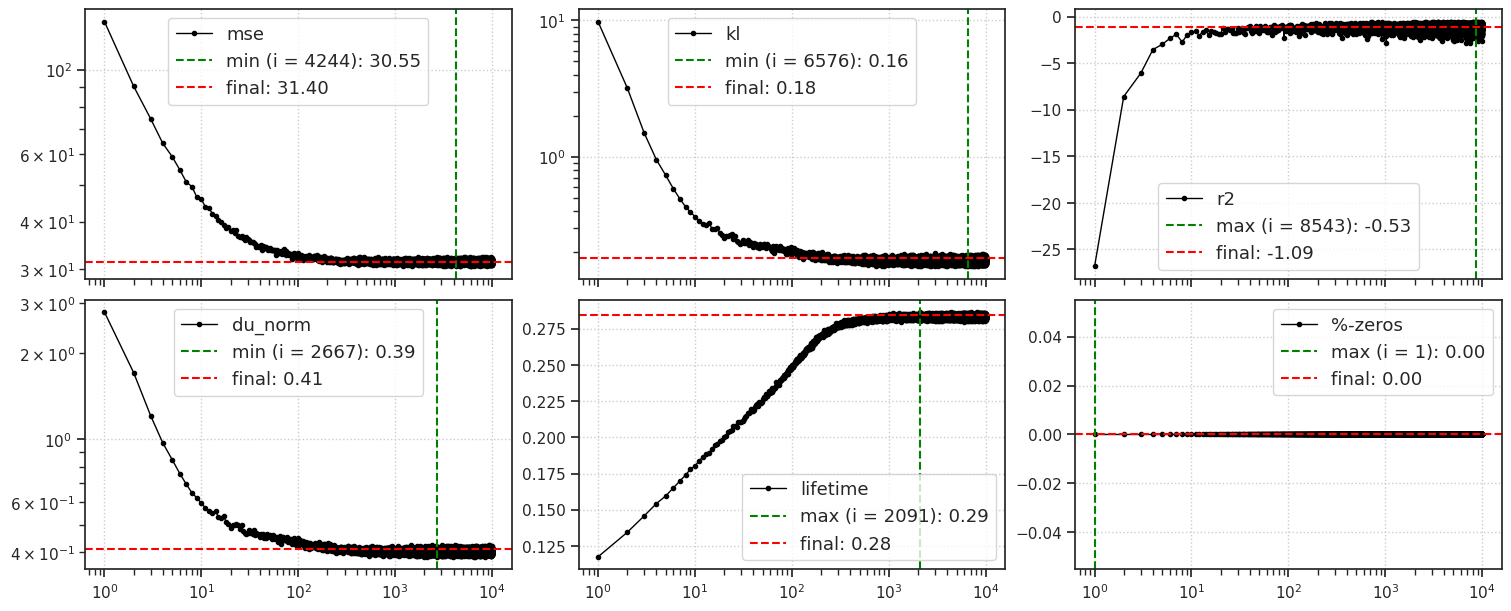

CPU times: user 39.7 s, sys: 1.68 s, total: 41.4 s
Wall time: 55 s


In [10]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [11]:
output = tr.xtract_ftr('vld', 1000, 100)
print(list(output))

100%|█████████████████████████████████| 50/50 [01:18<00:00,  1.58s/it]


['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [12]:
u = output['state'].copy()
z = output['samples'].copy()

u.shape, z.shape

((9801, 11, 100), (9801, 11, 100))

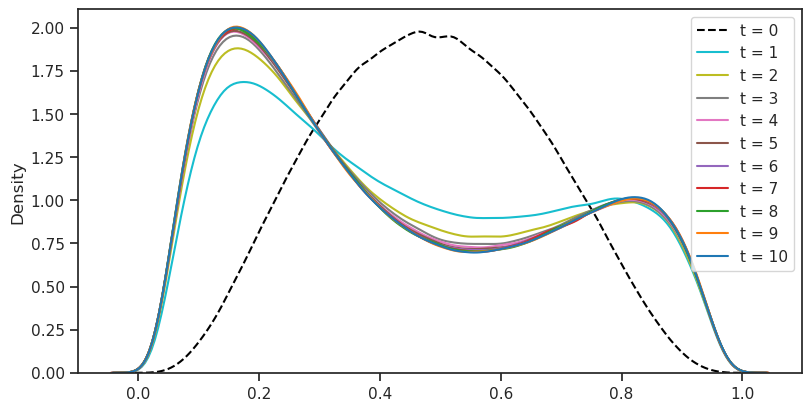

CPU times: user 3min 8s, sys: 7.24 s, total: 3min 15s
Wall time: 29.6 s


In [13]:
%%time


fig, ax = create_figure(1, 1, (8, 4))
for i in range(z.shape[1]):
    sns.kdeplot(
        z[:, i, :].ravel(),
        color=f'C{10-i}' if i > 0 else 'k',
        ls='-' if i > 0 else '--',
        label=f't = {i}',
    )
add_legend(ax)
plt.show()

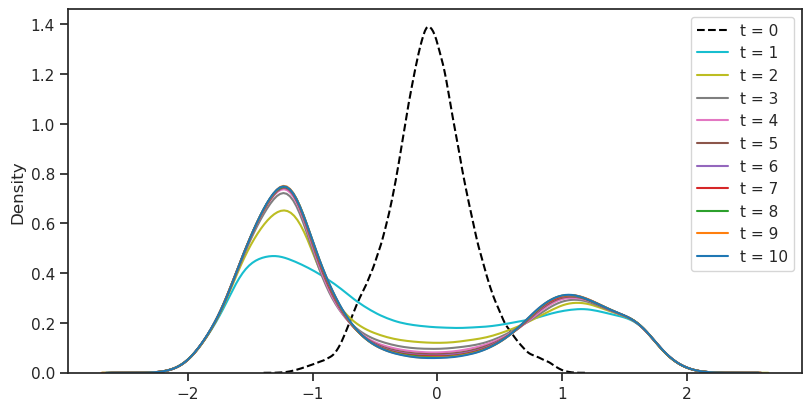

CPU times: user 3min 6s, sys: 7.1 s, total: 3min 13s
Wall time: 33.3 s


In [14]:
%%time


fig, ax = create_figure(1, 1, (8, 4))
for i in range(u.shape[1]):
    sns.kdeplot(
        u[:, i, :].ravel(),
        color=f'C{10-i}' if i > 0 else 'k',
        ls='-' if i > 0 else '--',
        label=f't = {i}',
    )
add_legend(ax)
plt.show()

In [15]:
print(sp_stats.pearsonr(u0, z.mean(0)[-1]))
print(sp_stats.spearmanr(u0, z.mean(0)[-1]))

PearsonRResult(statistic=0.9195378460909079, pvalue=1.5541326597702305e-41)

SignificanceResult(statistic=0.8934053405340533, pvalue=7.889551412992819e-36)

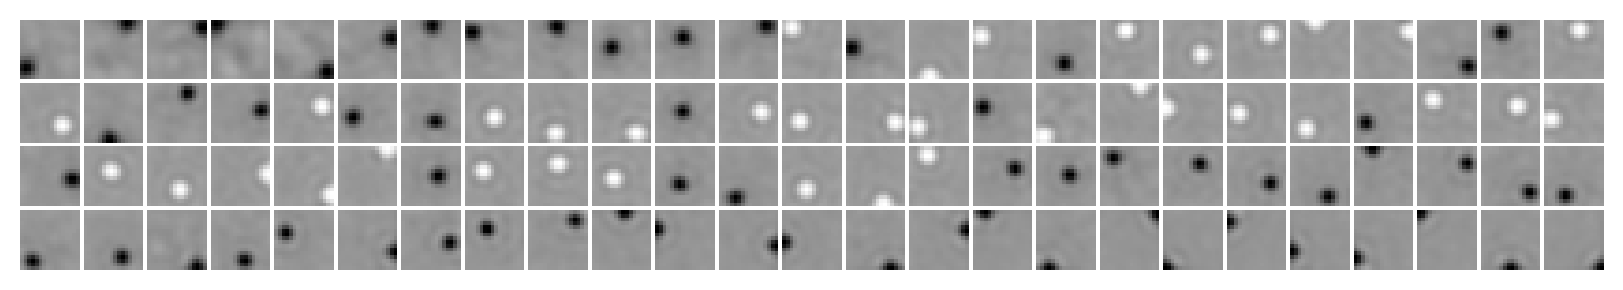

In [17]:
tr.model.show(order=np.argsort(u0), nrows=4, method='abs-max');

## Fit: ```z-192, (16, 32.0)```

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 192
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 32.0

cfg_tr['epochs']= 2000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |   50.0 K   |
|     ———     |    ———     |
|    layer    |   50.0 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[192]_u-(7,2),du-(7,3)_<grad|lin>
b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_13,00:09)

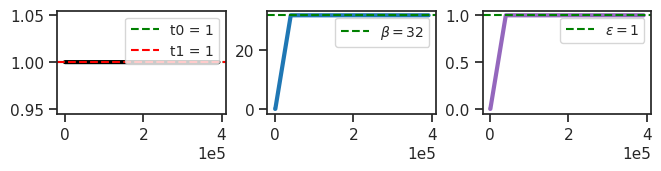

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

392000

In [6]:
print(tr.model.layer)

GaussianSigmoidLayer(input_dim=256, latent_dim=192, temperature=1, beta_inner=1, eps=1)

In [ ]:
# cm = f""
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

In [11]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0497], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0055], device='cuda:1', grad_fn=<ExpBackward0>))

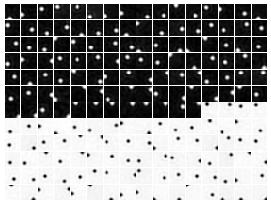

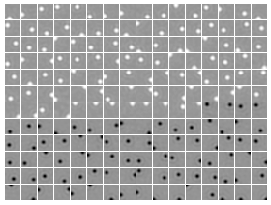

In [12]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=12, dpi=50)
tr.model.show(order=np.argsort(u0), nrows=12, dpi=50, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:33<00:00, 16.91s/it]


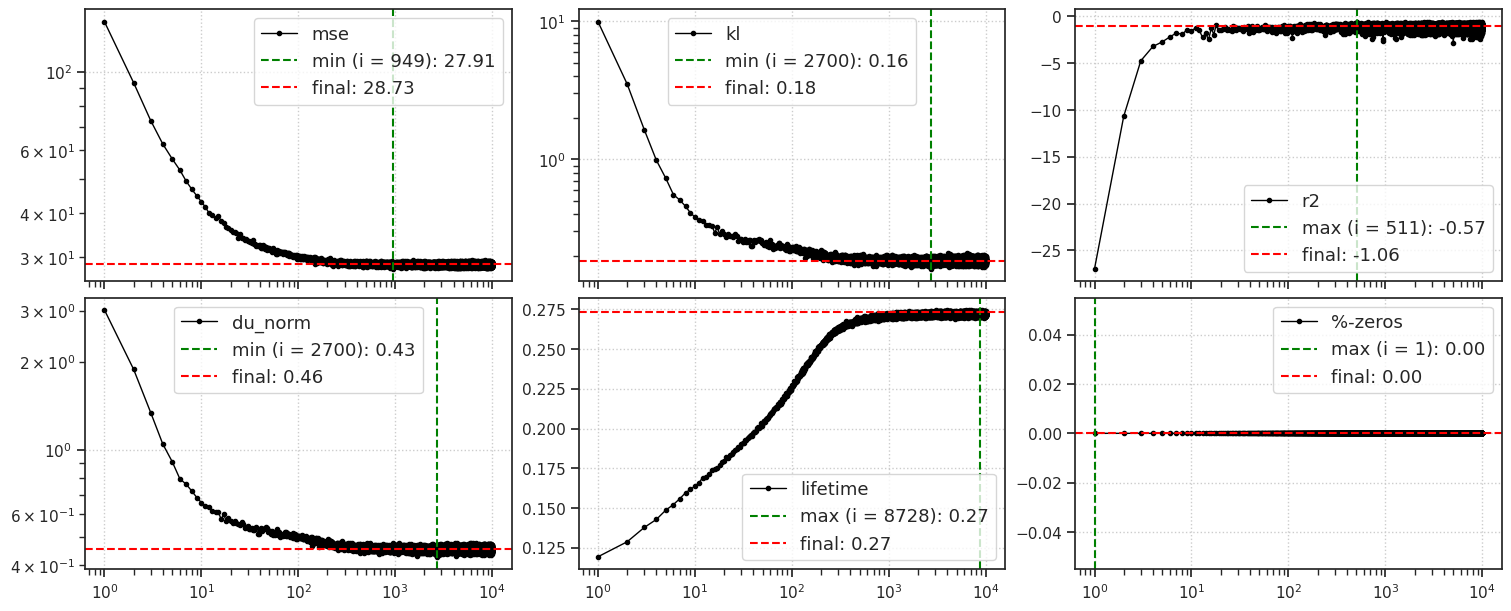

CPU times: user 39.9 s, sys: 2.73 s, total: 42.7 s
Wall time: 42.7 s


In [13]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

## Fit: ```z-128, (16, 32.0)```

In [3]:
model_type = 'gaussian'
cfg_vae, cfg_tr = default_configs(model_type, 'Kyoto16')

cfg_vae['n_latents'] = 128
cfg_vae['latent_act'] = 'sigmoid'

cfg_vae['seq_len'] = 16
cfg_tr['kl_beta'] = 32.0

cfg_tr['epochs']= 2000

cfg_tr['dataset_kws'] = {
    'file_name': 'patches.npy',
    'shift_rescale': True,
}

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|    IGVAE    |   33.4 K   |
|     ———     |    ———     |
|    layer    |   33.4 K   |
+-------------+------------+

gaussian_sigmoid_Kyoto16_t-16_z-[128]_u-(7,2),du-(7,3)_<grad|lin>
b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_12,15:22)

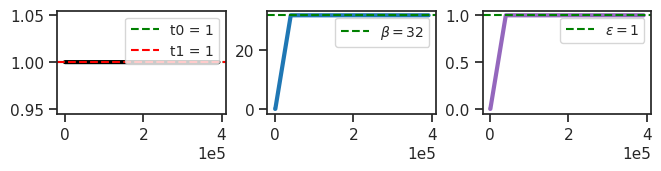

In [4]:
tr = Trainer(
    model=MODEL_CLASSES[model_type](CFG_CLASSES[model_type](**cfg_vae)),
    cfg=ConfigTrain(**cfg_tr),
    device=device,
)

tr.model.print()
print(f"{tr.model.cfg.name()}\n{tr.cfg.name()}_({tr.model.timestamp})\n")
tr.show_schedules()

In [5]:
tr.n_iters

392000

In [6]:
print(tr.model.layer)

GaussianSigmoidLayer(input_dim=256, latent_dim=128, temperature=1, beta_inner=1, eps=1)

In [7]:
# cm = f""
# tr.train(fit_name=f"{cm}_{tr.cfg.name()}")

tr.train()

epoch # 2000, avg loss: 214.982: 100%|████| 2000/2000 [8:18:46<00:00, 14.96s/it]


In [8]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0479], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0078], device='cuda:1', grad_fn=<ExpBackward0>))

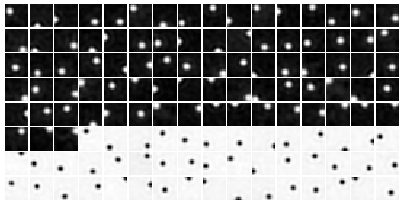

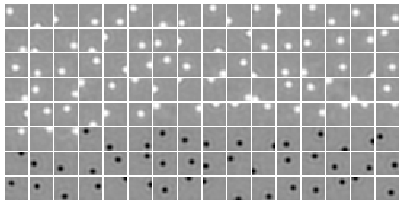

In [12]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=8, dpi=50)
tr.model.show(order=np.argsort(u0), nrows=8, dpi=50, method='abs-max');

100%|███████████████████████████████████| 2/2 [00:35<00:00, 17.64s/it]


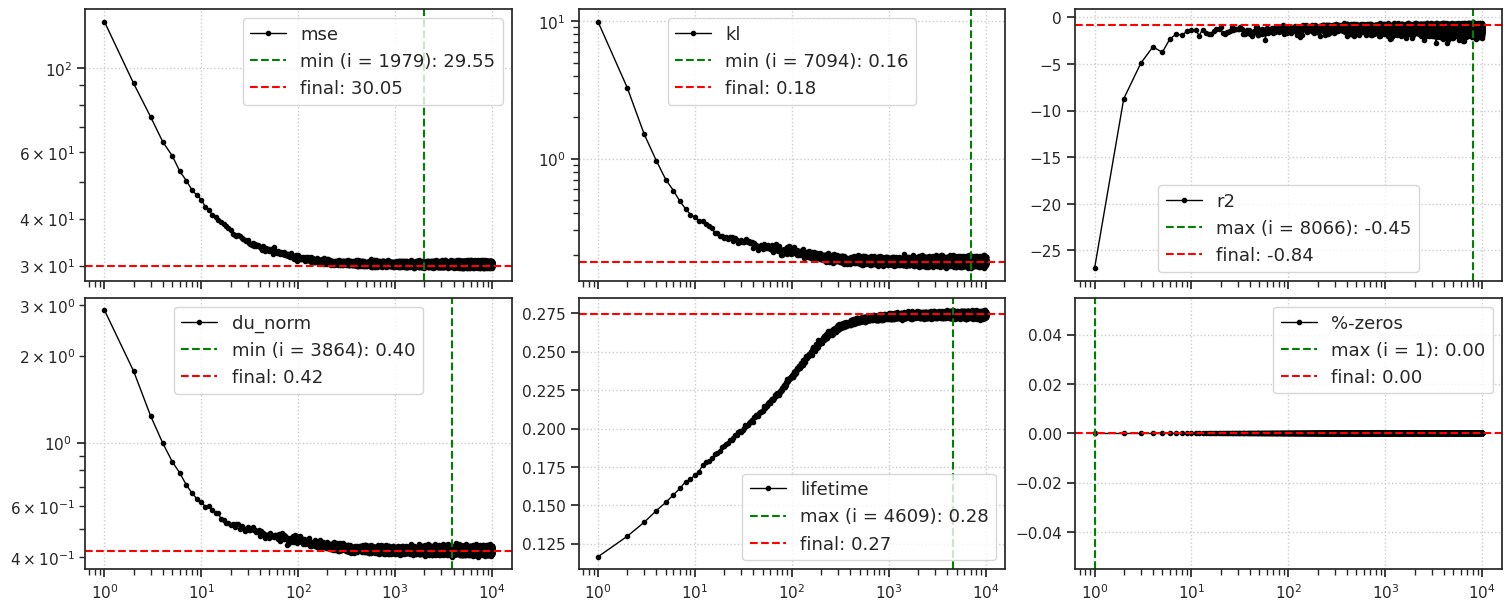

CPU times: user 39.9 s, sys: 1.86 s, total: 41.8 s
Wall time: 41.8 s


In [13]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [14]:
output = tr.xtract_ftr('vld', 1000, 100)
print(list(output))

100%|█████████████████████████████████| 50/50 [01:21<00:00,  1.62s/it]


['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [17]:
u = output['state'].copy()
z = output['samples'].copy()

u.shape, z.shape

((9801, 11, 128), (9801, 11, 128))

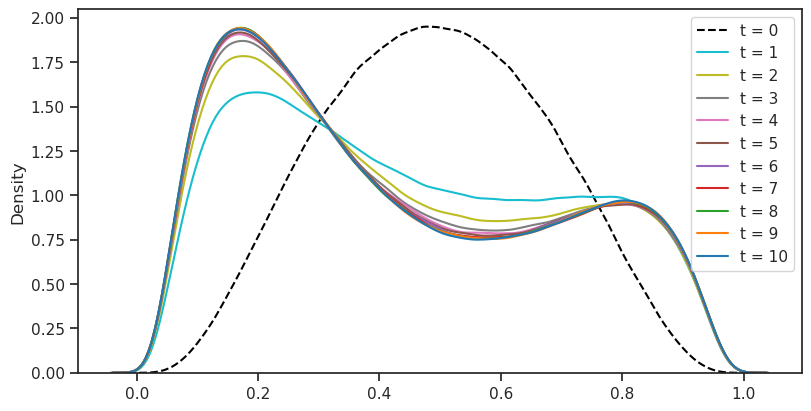

CPU times: user 3min 19s, sys: 5.8 s, total: 3min 25s
Wall time: 36.5 s


In [18]:
%%time


fig, ax = create_figure(1, 1, (8, 4))
for i in range(z.shape[1]):
    sns.kdeplot(
        z[:, i, :].ravel(),
        color=f'C{10-i}' if i > 0 else 'k',
        ls='-' if i > 0 else '--',
        label=f't = {i}',
    )
add_legend(ax)
plt.show()

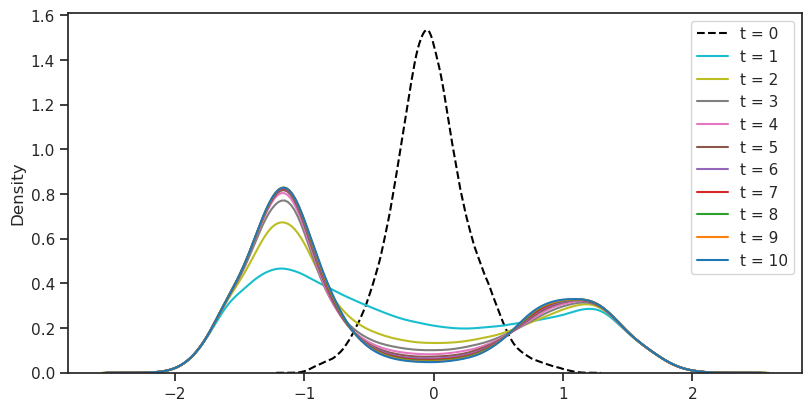

CPU times: user 3min 17s, sys: 5.7 s, total: 3min 23s
Wall time: 36.1 s


In [19]:
%%time


fig, ax = create_figure(1, 1, (8, 4))
for i in range(u.shape[1]):
    sns.kdeplot(
        u[:, i, :].ravel(),
        color=f'C{10-i}' if i > 0 else 'k',
        ls='-' if i > 0 else '--',
        label=f't = {i}',
    )
add_legend(ax)
plt.show()

In [20]:
print(sp_stats.pearsonr(u0, z.mean(0)[-1]))
print(sp_stats.spearmanr(u0, z.mean(0)[-1]))

PearsonRResult(statistic=0.8622832566694133, pvalue=4.820886199366393e-39)

SignificanceResult(statistic=0.7789839315143746, pvalue=2.6105555743780147e-27)

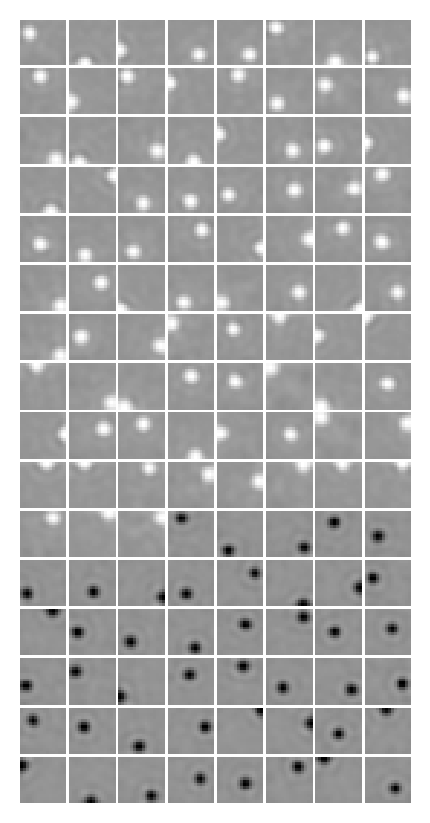

In [21]:
tr.model.show(order=np.argsort(u0), method='abs-max');

## Load & eval: ```z-256, (16, 32.0)```

In [3]:
a = 'gaussian_sigmoid_Kyoto16_t-16_z-[256]_u-(7,2),du-(7,3)_<grad|lin>'
b = 'b200-ep2000-lr(0.005)_beta(32:0.1)_gr(500)_(2025_03_11,23:39)'

tr, meta = load_model(f"{a}/{b}", device)
meta['checkpoint']

2000

In [4]:
tuple(llr.exp() for llr in tr.model.layer.log_lr)

(tensor([0.0505], device='cuda:1', grad_fn=<ExpBackward0>),
 tensor([0.0043], device='cuda:1', grad_fn=<ExpBackward0>))

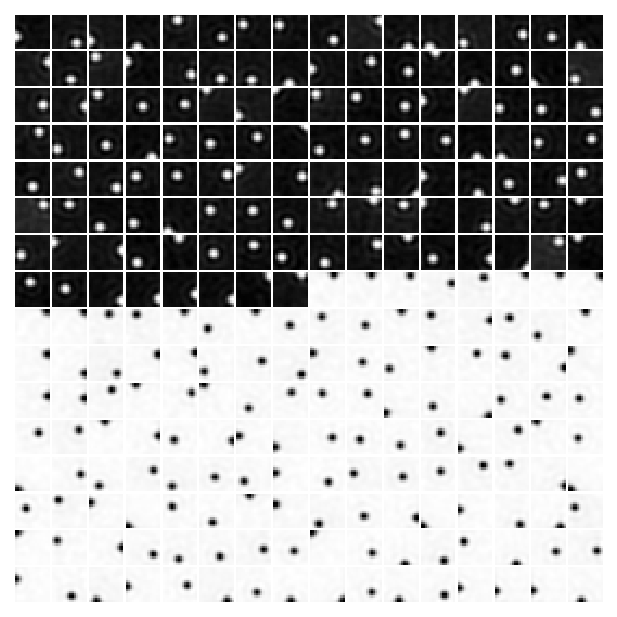

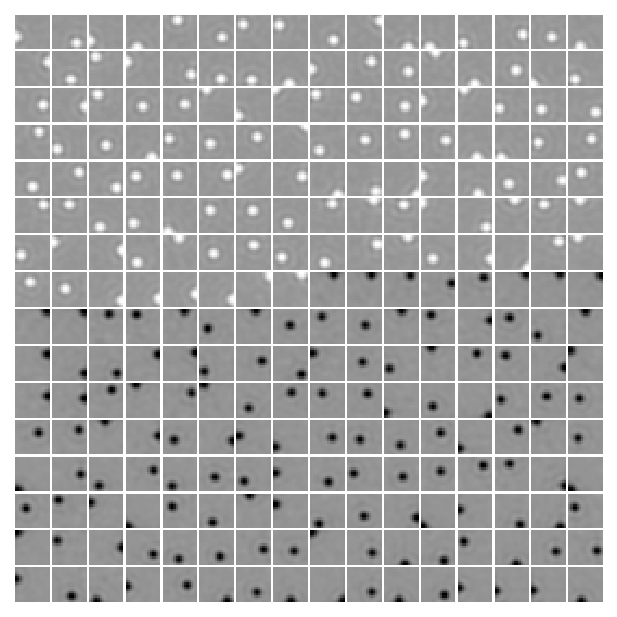

In [5]:
u0 = tonp(tr.model.layer.u_init[0].squeeze())
u1 = tonp(tr.model.layer.u_init[1].squeeze())
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150)
tr.model.show(order=np.argsort(u0), nrows=16, dpi=150, method='abs-max');

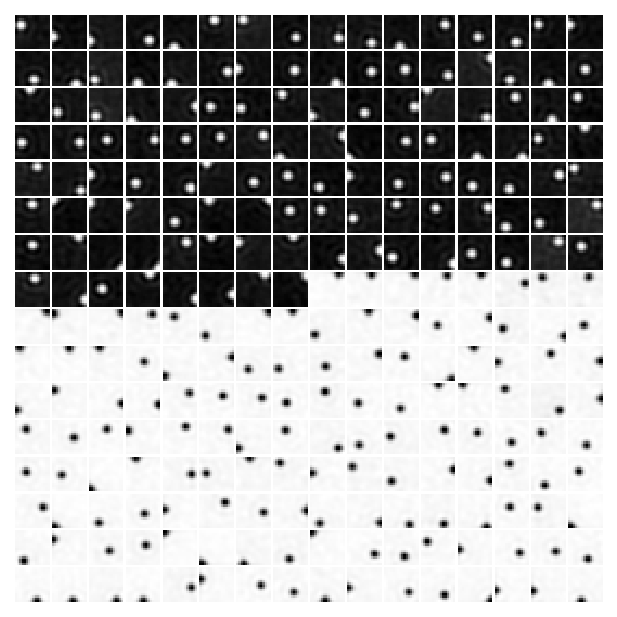

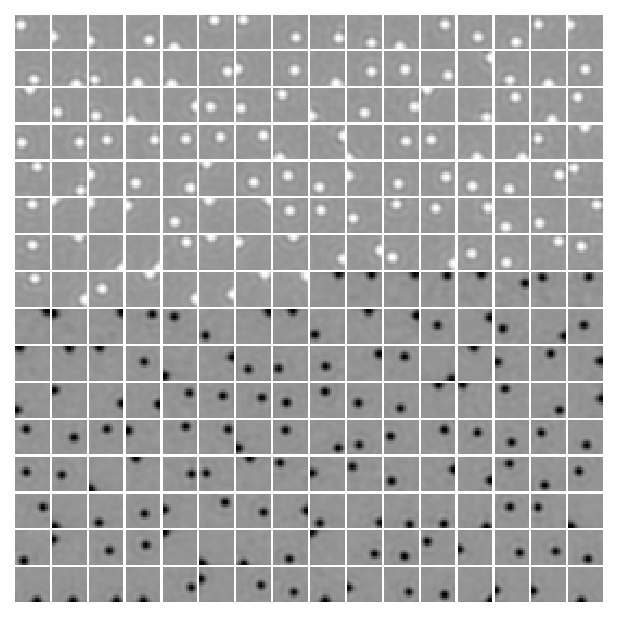

In [6]:
### Was: epoch = 1150

In [6]:
w = tr.model.layer.get_weight().T
absmax = torch.max(w.abs()).item()
# absmax = torch.max(w.abs(), dim=1, keepdims=True).values

w_rescaled = 0.5 * (w / absmax + 1)
w_rescaled = w_rescaled.reshape(-1, 16, 16)

w_rescaled.shape

torch.Size([256, 16, 16])

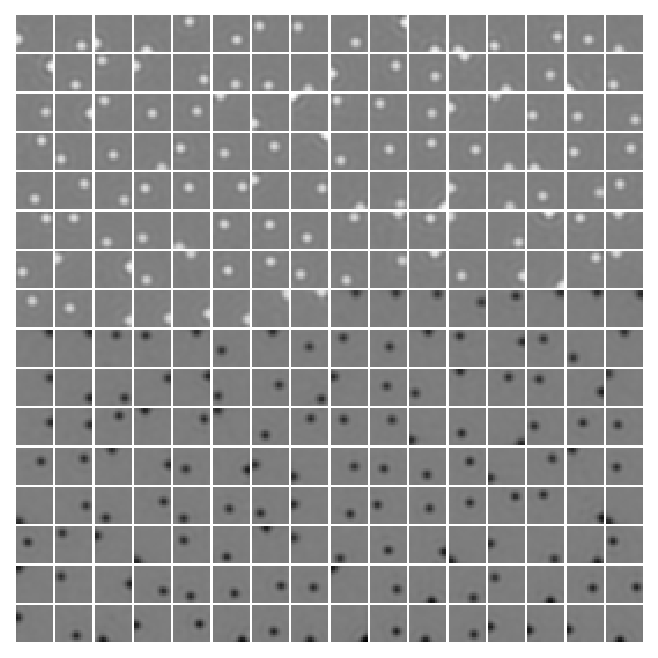

In [7]:
plot_weights(
    w=w_rescaled[np.argsort(u0)],
    method='none',
    vmin=0,
    vmax=1,
    cmap='Greys_r',
    nrows=16,
);

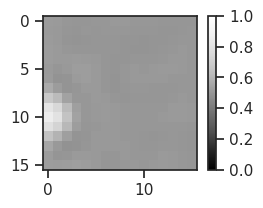

In [8]:
imshow(w_rescaled[np.argsort(u0)][0], cmap='Greys_r', vmin=0, vmax=1)
plt.colorbar()

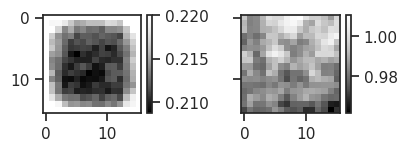

In [9]:
log_scale = tonp(tr.model.layer.get_dec_log_sigma().squeeze())
var_learned = (np.exp(log_scale) ** 2).reshape(16, 16)

var_data = tonp(tr.dl_vld.dataset.tensors[0].var(dim=0).squeeze())

fig, axes =  create_figure(1, 2, (4, 1.4), sharex='all', sharey='all')
im = axes[0].imshow(var_learned, cmap='Greys_r', vmax=np.quantile(var_learned, 0.75))
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(var_data, cmap='Greys_r')
plt.colorbar(im, ax=axes[1])

plt.show()

In [10]:
print(sp_stats.pearsonr(var_learned.ravel(), var_data.ravel()))

PearsonRResult(statistic=-0.1055934982712448, pvalue=0.0918065157035923)

100%|███████████████████████████████████| 2/2 [00:37<00:00, 18.62s/it]


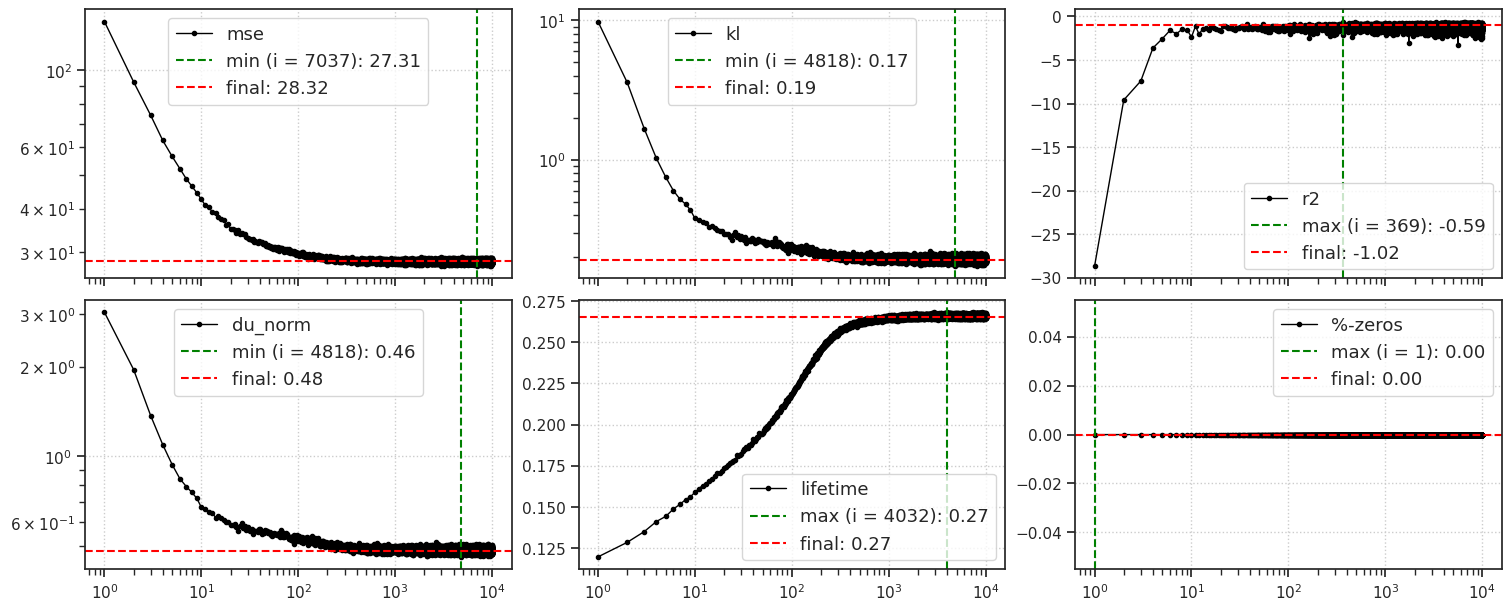

CPU times: user 44.9 s, sys: 4.42 s, total: 49.3 s
Wall time: 49.3 s


In [11]:
%%time

kws = dict(
    seq_total=10000,
    seq_batch_sz=1000,
    n_data_batches=2,
    compute_sprs=True,
)
results = tr.analysis('vld', **kws)
_ = plot_convergence(results, color='k')

In [12]:
output = tr.xtract_ftr('vld', 1000, 100)
print(list(output))

100%|█████████████████████████████████| 50/50 [01:17<00:00,  1.56s/it]


['r2', 'mse', 'state', 'samples', 'du_norm', 'times']

In [13]:
u = output['state'].copy()
z = output['samples'].copy()

u.shape, z.shape

((9801, 11, 256), (9801, 11, 256))

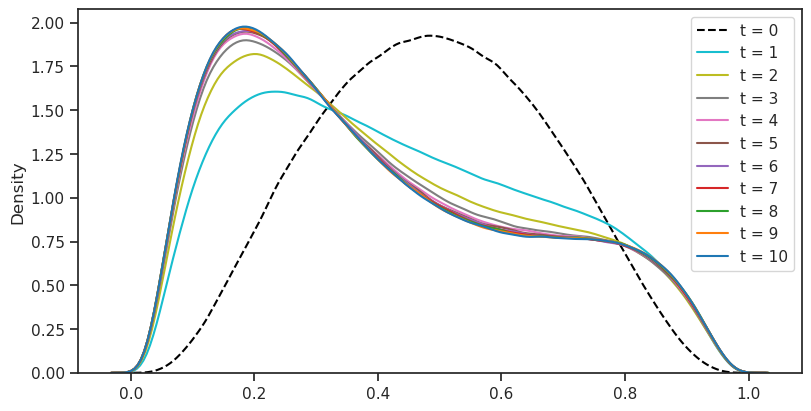

In [25]:
fig, ax = create_figure(1, 1, (8, 4))
for i in range(z.shape[1]):
    sns.kdeplot(
        z[:, i, :].ravel(),
        color=f'C{10-i}' if i > 0 else 'k',
        ls='-' if i > 0 else '--',
        label=f't = {i}',
    )
add_legend(ax)
plt.show()

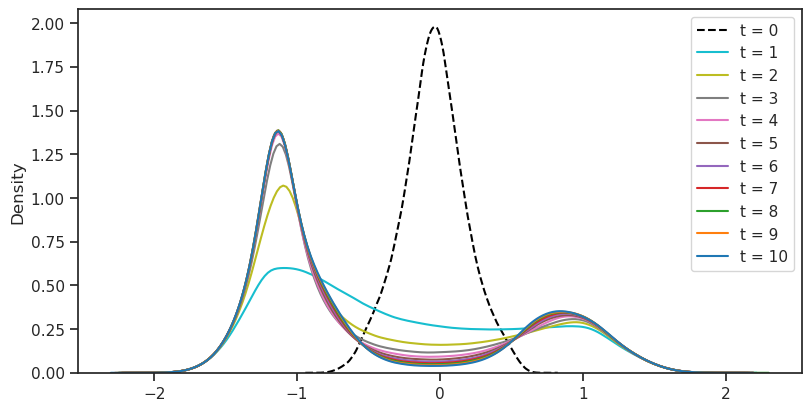

In [26]:
fig, ax = create_figure(1, 1, (8, 4))
for i in range(u.shape[1]):
    sns.kdeplot(
        u[:, i, :].ravel(),
        color=f'C{10-i}' if i > 0 else 'k',
        ls='-' if i > 0 else '--',
        label=f't = {i}',
    )
add_legend(ax)
plt.show()

In [27]:
print(sp_stats.pearsonr(u0, z.mean(0)[-1]))
print(sp_stats.spearmanr(u0, z.mean(0)[-1]))

PearsonRResult(statistic=0.6990507420910215, pvalue=7.20579761886419e-39)

SignificanceResult(statistic=0.6895985923552299, pvalue=1.8258499588175226e-37)

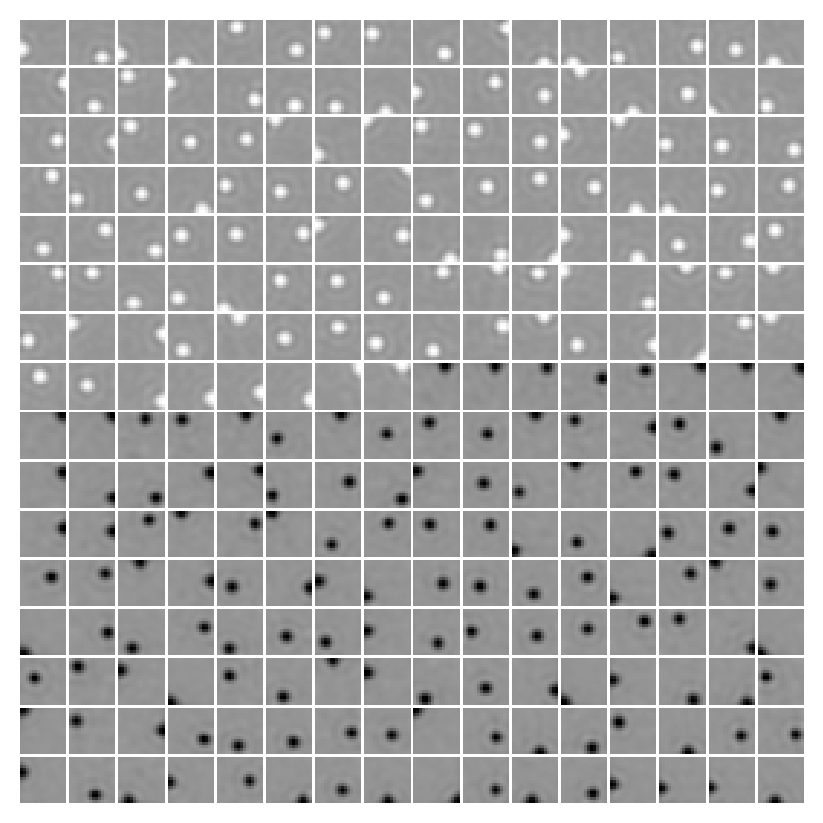

In [28]:
tr.model.show(order=np.argsort(u0), method='abs-max');